In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/ML/archive (2).zip"
extract_path = "/content/drive/MyDrive/ML/Datasets/plantvillage"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed")

Extraction completed


In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split
from tqdm import tqdm

SOURCE_DIR = "/content/drive/MyDrive/ML/Datasets/plantvillage/PlantVillage"
OUTPUT_DIR = "/content/drive/MyDrive/ML/dataset/stage1_leaf_classifier"

TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

random.seed(42)


def create_dirs():

    for split in ["train", "val", "test"]:
        for cls in ["potato_leaf", "other_leaf"]:
            os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

def collect_images():

    potato = []
    other = []

    for folder in os.listdir(SOURCE_DIR):

        folder_path = os.path.join(SOURCE_DIR, folder)

        if not os.path.isdir(folder_path):
            continue

        images = [os.path.join(folder_path, f)
                  for f in os.listdir(folder_path)
                  if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        if "Potato" in folder:
            potato.extend(images)
        else:
            other.extend(images)

    return potato, other


def balance_dataset(potato, other):

    min_count = min(len(potato), len(other))

    potato = random.sample(potato, min_count)
    other = random.sample(other, min_count)

    return potato, other


def split_dataset(data):

    train, temp = train_test_split(data, test_size=1-TRAIN_SPLIT, random_state=42)

    val, test = train_test_split(
        temp,
        test_size=TEST_SPLIT/(VAL_SPLIT+TEST_SPLIT),
        random_state=42
    )

    return train, val, test


def copy_files(file_list, split, label):

    dest_dir = os.path.join(OUTPUT_DIR, split, label)

    for file in tqdm(file_list, desc=f"{split}/{label}"):
        filename = os.path.basename(file)
        shutil.copy(file, os.path.join(dest_dir, filename))

def main():

    print("Creating directories...")
    create_dirs()

    print("Collecting images...")
    potato, other = collect_images()

    print("Potato images:", len(potato))
    print("Other images:", len(other))

    print("Balancing dataset...")
    potato, other = balance_dataset(potato, other)

    print("Balanced size:", len(potato))

    print("Splitting datasets...")

    p_train, p_val, p_test = split_dataset(potato)
    o_train, o_val, o_test = split_dataset(other)

    print("Copying files...")

    copy_files(p_train, "train", "potato_leaf")
    copy_files(p_val, "val", "potato_leaf")
    copy_files(p_test, "test", "potato_leaf")

    copy_files(o_train, "train", "other_leaf")
    copy_files(o_val, "val", "other_leaf")
    copy_files(o_test, "test", "other_leaf")

    print("Dataset preparation completed!")


if __name__ == "__main__":
    main()

Creating directories...
Potato images: 2152
Other images: 18484
Balancing dataset...
Balanced size: 2152
Splitting datasets...
Copying files...


test/other_leaf: 100%|██████████| 323/323 [00:06<00:00, 46.82it/s]

Dataset preparation completed!


In [ ]:
import os
import shutil
from tqdm import tqdm

MENDELEY_DIR = "/content/drive/MyDrive/ML/Datasets/mendeley/Plant_leave_diseases_dataset_without_augmentation"
PLANT_DIR = "/content/drive/MyDrive/ML/Datasets/plantvillage/PlantVillage"

OUTPUT_DIR = "/content/drive/MyDrive/ML/dataset/stage2_disease_classifier"

CLASSES = [
    "Potato___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight"
]

def create_dirs():

    for split in ["train", "test"]:
        for cls in CLASSES:
            os.makedirs(
                os.path.join(OUTPUT_DIR, split, cls),
                exist_ok=True
            )

def copy_class(src_root, split):

    for cls in CLASSES:

        src_folder = os.path.join(src_root, cls)
        dst_folder = os.path.join(OUTPUT_DIR, split, cls)

        if not os.path.exists(src_folder):
            print(f"Missing: {src_folder}")
            continue

        files = [
            f for f in os.listdir(src_folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        for file in tqdm(files, desc=f"{split} → {cls}"):

            src = os.path.join(src_folder, file)
            dst = os.path.join(dst_folder, file)

            shutil.copy(src, dst)

def main():

    print("Creating folders...")
    create_dirs()

    print("\nCopying TRAIN dataset (Mendeley)")
    copy_class(MENDELEY_DIR, "train")

    print("\nCopying TEST dataset (PlantVillage)")
    copy_class(PLANT_DIR, "test")

    print("\nDataset preparation completed!")


if __name__ == "__main__":
    main()

Creating folders...

Copying TRAIN dataset (Mendeley)


train → Potato___Late_blight: 100%|██████████| 1000/1000 [00:32<00:00, 30.77it/s]



Copying TEST dataset (PlantVillage)


test → Potato___Late_blight:  52%|█████▏    | 517/1000 [00:21<00:14, 34.23it/s]

In [ ]:
import os

OUTPUT_DIR = "/content/drive/MyDrive/ML/dataset/stage2_disease_classifier"

def count_split(split):

    split_path = os.path.join(OUTPUT_DIR, split)

    print(f"\n{split.upper()} DATASET\n")

    total = 0

    for cls in sorted(os.listdir(split_path)):

        cls_path = os.path.join(split_path, cls)

        if not os.path.isdir(cls_path):
            continue

        files = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ]

        count = len(files)
        total += count

        print(f"{cls:<30} {count}")

    print(f"\nTotal {split} images: {total}")


count_split("train")
count_split("test")


TRAIN DATASET

Potato___Early_blight          1000
Potato___Late_blight           1000
Potato___healthy               152

Total train images: 2152

TEST DATASET

Potato___Early_blight          1000
Potato___Late_blight           1000
Potato___healthy               152

Total test images: 2152


In [ ]:
import os
import random

OUTPUT_DIR = "/content/drive/MyDrive/ML/dataset/stage2_disease_classifier"

CLASSES = [
    "Potato___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight"
]

random.seed(42)

def balance_split(split):

    split_path = os.path.join(OUTPUT_DIR, split)

    counts = {}

    for cls in CLASSES:

        folder = os.path.join(split_path, cls)

        files = [
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ]

        counts[cls] = files

    min_count = min(len(v) for v in counts.values())

    print(f"\nBalancing {split} to {min_count} images per class")

    for cls, files in counts.items():

        folder = os.path.join(split_path, cls)

        if len(files) > min_count:

            remove_files = random.sample(files, len(files) - min_count)

            for f in remove_files:
                os.remove(os.path.join(folder, f))


balance_split("train")
balance_split("test")

print("\nDataset balanced.")


Balancing train to 152 images per class

Balancing test to 152 images per class

Dataset balanced.


In [ ]:
import os

OUTPUT_DIR = "/content/drive/MyDrive/ML/dataset/stage2_disease_classifier"

def count_split(split):

    split_path = os.path.join(OUTPUT_DIR, split)

    print(f"\n{split.upper()} DATASET\n")

    total = 0

    for cls in sorted(os.listdir(split_path)):

        cls_path = os.path.join(split_path, cls)

        if not os.path.isdir(cls_path):
            continue

        files = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ]

        count = len(files)
        total += count

        print(f"{cls:<30} {count}")

    print(f"\nTotal {split} images: {total}")


count_split("train")
count_split("test")


TRAIN DATASET

Potato___Early_blight          152
Potato___Late_blight           152
Potato___healthy               152

Total train images: 456

TEST DATASET

Potato___Early_blight          152
Potato___Late_blight           152
Potato___healthy               152

Total test images: 456


In [ ]:
import os
import random
import shutil

OUTPUT_DIR = "/content/drive/MyDrive/ML/dataset/stage2_disease_classifier"

CLASSES = [
    "Potato___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight"
]

SWAP_PERCENT = 0.2   # swap 10%

random.seed(42)


def shuffle_split():

    for cls in CLASSES:

        train_path = os.path.join(OUTPUT_DIR, "train", cls)
        test_path = os.path.join(OUTPUT_DIR, "test", cls)

        train_files = [
            f for f in os.listdir(train_path)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ]

        test_files = [
            f for f in os.listdir(test_path)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ]

        swap_count = int(min(len(train_files), len(test_files)) * SWAP_PERCENT)

        print(f"\nSwapping {swap_count} images for {cls}")

        train_swap = random.sample(train_files, swap_count)
        test_swap = random.sample(test_files, swap_count)

        # temporary folder for safe swapping
        temp_dir = os.path.join(OUTPUT_DIR, "temp_swap")
        os.makedirs(temp_dir, exist_ok=True)

        # move train images to temp
        for f in train_swap:
            shutil.move(os.path.join(train_path, f), os.path.join(temp_dir, f))

        # move test → train
        for f in test_swap:
            shutil.move(os.path.join(test_path, f), os.path.join(train_path, f))

        # move temp → test
        for f in train_swap:
            shutil.move(os.path.join(temp_dir, f), os.path.join(test_path, f))

        shutil.rmtree(temp_dir)


shuffle_split()

print("\nTrain/Test shuffle completed.")


Swapping 30 images for Potato___healthy

Swapping 30 images for Potato___Early_blight

Swapping 30 images for Potato___Late_blight

Train/Test shuffle completed.


In [ ]:
import os

OUTPUT_DIR = "/content/drive/MyDrive/ML/dataset/stage2_disease_classifier"

def check_leakage():

    duplicates = []

    for cls in os.listdir(os.path.join(OUTPUT_DIR, "train")):

        train_path = os.path.join(OUTPUT_DIR, "train", cls)
        test_path = os.path.join(OUTPUT_DIR, "test", cls)

        train_files = set(os.listdir(train_path))
        test_files = set(os.listdir(test_path))

        overlap = train_files.intersection(test_files)

        if overlap:
            duplicates.extend(overlap)

    if duplicates:
        print("Duplicate images found:", len(duplicates))
    else:
        print("No train-test leakage detected.")


check_leakage()

No train-test leakage detected.


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

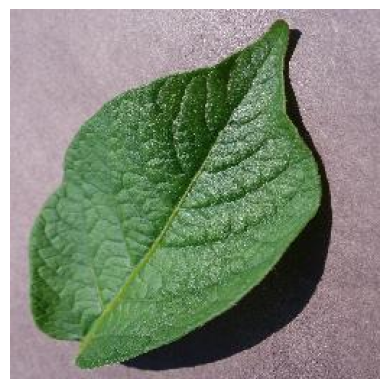

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

folder = "/content/drive/MyDrive/ML/dataset/stage2_disease_classifier/train/Potato___healthy"

img = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img)

plt.imshow(Image.open(img_path))
plt.axis("off")

In [ ]:
import os

OUTPUT_DIR = "/content/drive/MyDrive/ML/dataset/stage1_leaf_classifier"

def count_split(split):

    split_path = os.path.join(OUTPUT_DIR, split)

    print(f"\n{split.upper()} DATASET\n")

    total = 0

    for cls in sorted(os.listdir(split_path)):

        cls_path = os.path.join(split_path, cls)

        if not os.path.isdir(cls_path):
            continue

        files = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ]

        count = len(files)
        total += count

        print(f"{cls:<20} {count}")

    print(f"\nTotal {split} images: {total}")


# Count all splits
count_split("train")
count_split("val")
count_split("test")


TRAIN DATASET

other_leaf           1506
potato_leaf          1506

Total train images: 3012

VAL DATASET

other_leaf           323
potato_leaf          323

Total val images: 646

TEST DATASET

other_leaf           323
potato_leaf          323

Total test images: 646


In [6]:
import os
import shutil
import random
from tqdm import tqdm

# =========================
# PATHS
# =========================

PLANT_DIR = "/content/drive/MyDrive/ML/Datasets/plantvillage/PlantVillage"

VIPOOL_TRAIN = "/content/drive/MyDrive/ML/Datasets/vipool/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VIPOOL_VAL = "/content/drive/MyDrive/ML/Datasets/vipool/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

MENDELEY_DIR = "/content/drive/MyDrive/ML/Datasets/mendeley/Plant_leave_diseases_dataset_without_augmentation"

OUTPUT_DIR = "/content/drive/MyDrive/ML/dataset/stage1_leaf_classifier"

random.seed(42)

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
    print("Old dataset deleted")


for split in ["train","val","test"]:
    for cls in ["potato_leaf","other_leaf"]:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)


def collect_images(dataset_path):

    potato = []
    other = []

    for folder in os.listdir(dataset_path):

        folder_path = os.path.join(dataset_path, folder)

        if not os.path.isdir(folder_path):
            continue

        files = [
            os.path.join(folder_path, f)
            for f in os.listdir(folder_path)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ]

        if folder.startswith("Potato"):
            potato.extend(files)
        else:
            other.extend(files)

    return potato, other

# =========================
# BALANCE
# =========================

def balance(potato, other):

    min_count = min(len(potato), len(other))

    potato = random.sample(potato, min_count)
    other = random.sample(other, min_count)

    return potato, other

# =========================
# COPY FILES
# =========================

def copy_files(files, split, label):

    dest = os.path.join(OUTPUT_DIR, split, label)

    for f in tqdm(files, desc=f"{split}/{label}"):
        shutil.copy(f, os.path.join(dest, os.path.basename(f)))

# =========================
# PROCESS SPLIT
# =========================

def process_split(dataset_path, split_name):

    print(f"\nProcessing {split_name} from {dataset_path}")

    potato, other = collect_images(dataset_path)

    print("Before balance:")
    print("Potato:", len(potato))
    print("Other :", len(other))

    potato, other = balance(potato, other)

    print("After balance:", len(potato))

    copy_files(potato, split_name, "potato_leaf")
    copy_files(other, split_name, "other_leaf")

# =========================
# MAIN
# =========================

# Train → PlantVillage
process_split(PLANT_DIR, "train")

# Val → Vipool (use VALID folder)
process_split(VIPOOL_VAL, "val")

# Test → Mendeley
process_split(MENDELEY_DIR, "test")

print("\nStage-1 dataset created successfully!")

Old dataset deleted

Processing train from /content/drive/MyDrive/ML/Datasets/plantvillage/PlantVillage
Before balance:
Potato: 2152
Other : 18484
After balance: 2152


train/other_leaf: 100%|██████████| 2152/2152 [01:16<00:00, 28.17it/s]



Processing val from /content/drive/MyDrive/ML/Datasets/vipool/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Before balance:
Potato: 1426
Other : 16146
After balance: 1426


val/other_leaf: 100%|██████████| 1426/1426 [00:49<00:00, 28.70it/s]



Processing test from /content/drive/MyDrive/ML/Datasets/mendeley/Plant_leave_diseases_dataset_without_augmentation
Before balance:
Potato: 2152
Other : 41897
After balance: 2152


test/other_leaf: 100%|██████████| 2152/2152 [02:55<00:00, 12.24it/s]


Stage-1 dataset created successfully!


In [3]:
import os

OUTPUT_DIR = "/content/drive/MyDrive/ML/dataset/stage1_leaf_classifier"

def count_split(split):

    split_path = os.path.join(OUTPUT_DIR, split)

    print(f"\n{split.upper()} DATASET\n")

    total = 0

    for cls in sorted(os.listdir(split_path)):

        cls_path = os.path.join(split_path, cls)

        if not os.path.isdir(cls_path):
            continue

        files = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ]

        count = len(files)
        total += count

        print(f"{cls:<20} {count}")

    print(f"\nTotal {split} images: {total}")


# Count all splits
count_split("train")
count_split("val")
count_split("test")


TRAIN DATASET

other_leaf           2152
potato_leaf          2152

Total train images: 4304

VAL DATASET

other_leaf           1426
potato_leaf          1426

Total val images: 2852

TEST DATASET

other_leaf           1331
potato_leaf          1000

Total test images: 2331
